## Imports

In [1]:
from keras import layers, optimizers, Input, Model, callbacks, regularizers
from methods.load_data import load_ucsf
from methods.visualisation import plot_training_history, plot_tumour

IMAGE_SIZE = 128

c:\Users\GGPC\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


loading dataset...
dataset loaded.
No data leakage of patient ids in train, validation and test splits


## Get dataset

loading dataset...
dataset loaded.
No data leakage of patient ids in train, validation and test splits
Training shape: x_train - (46500, 128, 128, 3), y_train - (46500,)
Validation shape: x_val - (18600, 128, 128, 3), y_val - (18600,)
Testing shape: x_test - (12555, 128, 128, 3), y_test - (12555,)


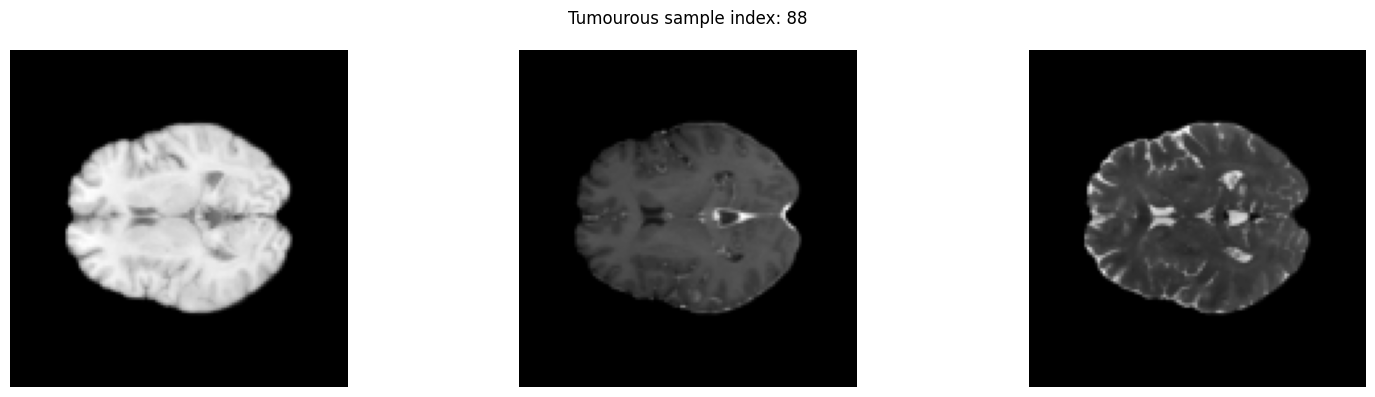

In [2]:
x_train, y_train, x_val, y_val, x_test, y_test = load_ucsf(debug=False, classification=True, image_size=IMAGE_SIZE)
print(f"Training shape: x_train - {x_train.shape}, y_train - {y_train.shape}")
print(f"Validation shape: x_val - {x_val.shape}, y_val - {y_val.shape}")
print(f"Testing shape: x_test - {x_test.shape}, y_test - {y_test.shape}")
plot_tumour(x_train, y_train)

## Construct model

In [3]:
regulariser = regularizers.l2(1e-4)
inputs = Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
x = layers.Conv2D(64, (3, 3), activation="relu", padding="same", kernel_regularizer=regulariser)(inputs)
x = layers.Dropout(0.5)(x)
x = layers.MaxPooling2D((2, 2), padding="same")(x)
x = layers.Conv2D(32, (3, 3), activation="relu", padding="same", kernel_regularizer=regulariser)(x)
x = layers.Dropout(0.5)(x)
x = layers.Conv2D(16, (3, 3), activation="relu", padding="same", kernel_regularizer=regulariser)(x)
x = layers.MaxPooling2D((2, 2), padding="same")(x)
x = layers.Conv2D(8, (3, 3), activation="relu", padding="same", kernel_regularizer=regulariser)(x)
x = layers.Dropout(0.3)(x)
x = layers.Flatten()(x)
output = layers.Dense(1, activation="sigmoid")(x)
model = Model(inputs=inputs, outputs=output)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32, 32, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         8,193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,233 (133.72 KB)

 Trainable params: 34,233 (133.72 KB)

 Non-trainable params: 0 (0.00 B)

## Compile model

In [4]:
model.compile(
    optimizer=optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["AUC"]
)

## Fit model

In [5]:
BATCH_SIZE = 32
EPOCHS = 50

def get_callbacks():
    return [
        callbacks.EarlyStopping(
            monitor="val_loss",
            patience=6,
            restore_best_weights=True
        ),
        callbacks.ModelCheckpoint(
            filepath="models/best_classification_model.keras",
            monitor="val_AUC",
            save_best_only=True,
            mode="max"
        )
    ]

history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    callbacks=get_callbacks(),
    batch_size=BATCH_SIZE,
    verbose=1
)

Epoch 1/50
1454/1454 ━━━━━━━━━━━━━━━━━━━━ 368s 252ms/step - AUC: 0.7767 - loss: 0.7782 - val_AUC: 0.8458 - val_loss: 0.5706
Epoch 2/50
1454/1454 ━━━━━━━━━━━━━━━━━━━━ 360s 248ms/step - AUC: 0.8591 - loss: 0.4567 - val_AUC: 0.8524 - val_loss: 0.5587
Epoch 3/50
1454/1454 ━━━━━━━━━━━━━━━━━━━━ 361s 248ms/step - AUC: 0.8721 - loss: 0.4363 - val_AUC: 0.8578 - val_loss: 0.5538
Epoch 4/50
1454/1454 ━━━━━━━━━━━━━━━━━━━━ 358s 246ms/step - AUC: 0.8836 - loss: 0.4181 - val_AUC: 0.8629 - val_loss: 0.5654
Epoch 5/50
1454/1454 ━━━━━━━━━━━━━━━━━━━━ 362s 249ms/step - AUC: 0.8950 - loss: 0.3983 - val_AUC: 0.8754 - val_loss: 0.5235
Epoch 6/50
1454/1454 ━━━━━━━━━━━━━━━━━━━━ 358s 246ms/step - AUC: 0.9205 - loss: 0.3507 - val_AUC: 0.9225 - val_loss: 0.3990
Epoch 7/50
1454/1454 ━━━━━━━━━━━━━━━━━━━━ 366s 252ms/step - AUC: 0.9403 - loss: 0.3022 - val_AUC: 0.9243 - val_loss: 0.4181
Epoch 8/50
1454/1454 ━━━━━━━━━━━━━━━━━━━━ 359s 247ms/step - AUC: 0.9489 - loss: 0.2810 - val_AUC: 0.9396 - val_loss: 0.3372
Epoch 9/

## Plot training and validation history

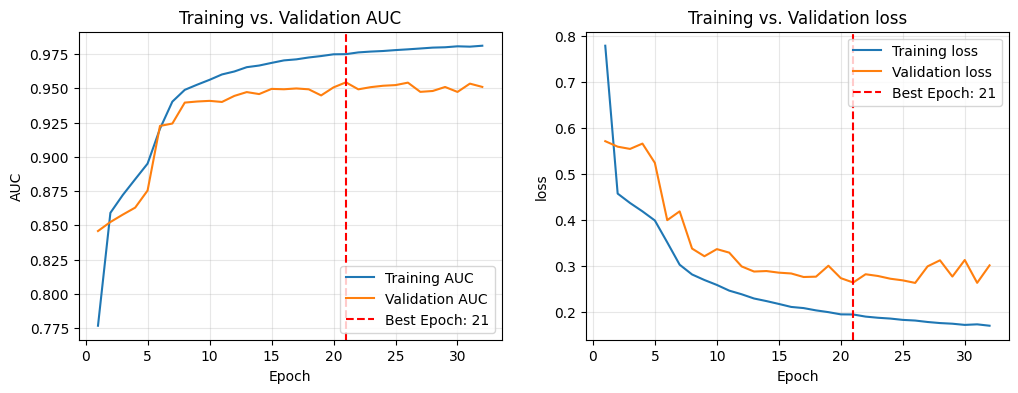

In [6]:
plot_training_history(history, "AUC", "loss")

## Evaluate model

In [7]:
loss, auc = model.evaluate(x_test, y_test)
print(f"Test loss: {loss}, Test AUC: {auc}")

393/393 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - AUC: 0.9483 - loss: 0.2740
Test loss: 0.27403974533081055, Test AUC: 0.948284387588501


## Notes
Plateauing around 80% AUC, validation loss is flat, best epoch is found early. Model started overfitting to quickly so implemented regulariser and dropout. Added maxpooling and increased image size.